In [147]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from sklearn.linear_model import Lasso, LassoCV, LinearRegression, Ridge
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error


In [102]:
df1 = pd.read_csv('output_with_sentiment_class.csv')
selected_types = ['Earnings', 'New Products']
df1['selected'] = df1['category'].apply(lambda x: 1 if x in selected_types else 0)
df1['sentiment_score'] *= df1['selected']

df2 = pd.read_csv('../input/jpx-tokyo-stock-exchange-prediction/train_files/stock_prices.csv')
df3 = pd.read_csv('../input/jpx-tokyo-stock-exchange-prediction//stock_list.csv')
df1['date'] = pd.to_datetime(df1['date']).dt.strftime('%Y-%m-%d')
df2['Date'] = pd.to_datetime(df2['Date']).dt.strftime('%Y-%m-%d')
mapping = dict(zip(df3['SecuritiesCode'], df3['Name']))
reverse_mapping = {v: k for k, v in mapping.items()}
df1['SecuritiesCode'] = df1['company name'].map(reverse_mapping)
df1.rename(columns={"date": "Date"}, inplace=True)

df2 = df2[df2['Date'] >= '2020-01-01']
df2 = df2[df2['Date'] <= '2020-12-31']
df2 = df2[df2['SecuritiesCode'].isin(df1['SecuritiesCode'].unique())]
df2['ExpectedDividend'].fillna(0, inplace=True)
print(f"securities code: {df1['SecuritiesCode'].unique()}")
df1.head(3)

securities code: [6861 6758 7203]


,Unnamed: 0,Date,company name,contents,sentiment_score,category,selected,SecuritiesCode
0,0,2020-01-31,KEYENCE CORPORATION,Released consolidated financial results for th...,0.00,Management,0,6861
1,1,2020-01-29,KEYENCE CORPORATION,"Announced the IV-H Series vision sensor, enhan...",0.25,New Products,1,6861
2,2,2020-01-14,KEYENCE CORPORATION,Introduced the LJ-X8000 series of 2D/3D laser ...,0.00,New Products,1,6861


In [105]:
df1_small = df1[['Date', 'SecuritiesCode', 'sentiment_score']].copy()
merged_df = df2.merge(
    df1_small,
    on = ["Date", "SecuritiesCode"],
    how='left'
)
merged_df["sentiment_score"] = merged_df["sentiment_score"].fillna(0)
df_numeric = merged_df.select_dtypes(include=['float64', 'int64'])
df_numeric.head(5)

,SecuritiesCode,Open,High,Low,Close,Volume,AdjustmentFactor,ExpectedDividend,Target,sentiment_score
0,6758,7331.0,7429.0,7325.0,7420.0,5154100,1.0,0.0,0.000653,0.0000
1,6861,38500.0,38970.0,38330.0,38970.0,708700,1.0,0.0,-0.006358,0.0000
2,7203,7599.0,7626.0,7530.0,7565.0,6672300,1.0,0.0,-0.012703,0.0000
3,6758,7542.0,7703.0,7532.0,7655.0,11720000,1.0,0.0,0.018799,0.5267
4,6861,39350.0,39780.0,39220.0,39320.0,511300,1.0,0.0,0.019196,0.0000


In [106]:
sentiment_scores = merged_df['sentiment_score'].values
targets = merged_df['Target'].values

# Correlation between sentiment scores and Target
sentiment_corr, sentiment_pval = pearsonr(sentiment_scores, targets)
print(f"Sentiment Score vs Target Correlation: {sentiment_corr:.4f}, p-value: {sentiment_pval:.4f}")

Sentiment Score vs Target Correlation: 0.1143, p-value: 0.0013


In [107]:
corr_matrix = df_numeric.corr()

# Print the correlation between each feature and the Target column
print("Correlation with Target:")
print(corr_matrix['Target'])

Correlation with Target:
SecuritiesCode     -0.045926
Open                0.026427
High                0.026882
Low                 0.025314
Close               0.025601
Volume              0.014032
AdjustmentFactor         NaN
ExpectedDividend    0.015097
Target              1.000000
sentiment_score     0.114298
Name: Target, dtype: float64


### Prediction

In [149]:
X = df_numeric.drop(columns=['Target'])
y = df_numeric['Target']
X.fillna(0, inplace=True)
y.fillna(0, inplace=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

R2 score: -0.002488052184299372


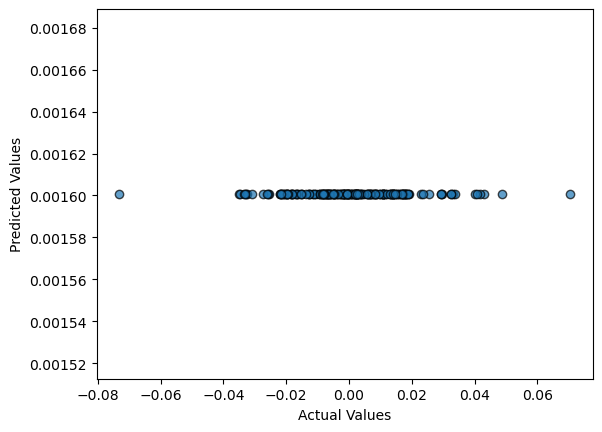

In [ ]:
model = Lasso(alpha=0.1,       
              max_iter=10_000,
              tol=1e-4,
              random_state=0)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
print(f"R2 score: {r2}")

plt.scatter(y_test, y_pred, edgecolor='k', alpha=0.7)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

plt.show()

In [144]:
print(model.coef_)

[-4.77201876e-08  0.00000000e+00  2.96056252e-06 -2.97873103e-06
 -0.00000000e+00  1.32396126e-10  0.00000000e+00  0.00000000e+00
  0.00000000e+00]


In [145]:
features = ['ExpectedDividend']
X = df_numeric.drop(columns=['Target'])
X = X[features]
y = df_numeric['Target']
X.fillna(0, inplace=True)
y.fillna(0, inplace=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [148]:
ridge = Ridge(alpha=1.0,        # regularization strength
              max_iter=10_000,
              tol=1e-4,
              random_state=0)

ridge.fit(X_train_scaled, y_train)

print("Coefficients:", ridge.coef_)
print("Train RMSE:", mean_squared_error(y_train, ridge.predict(X_train_scaled), squared=False))
print("Test  RMSE:", mean_squared_error(y_test,  ridge.predict(X_test_scaled),  squared=False))

Coefficients: [0.00085982]
Train RMSE: 0.019175500261514017
Test  RMSE: 0.01773831463150145


d:\Program Files\anaconda3\envs\dan\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
d:\Program Files\anaconda3\envs\dan\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
